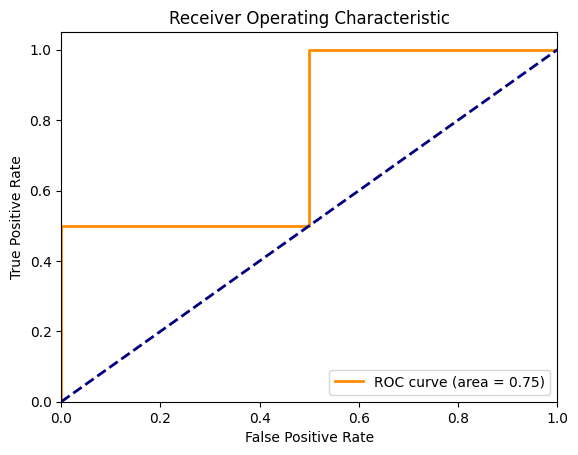

AUC: 0.75


In [4]:
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Example true labels and predicted probabilities
y_true = np.array([0, 0, 1, 1])
y_scores = np.array([0.1, 0.4, 0.35, 0.8])

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Calculate the AUC
auc = roc_auc_score(y_true, y_scores)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(f'AUC: {auc:.2f}')

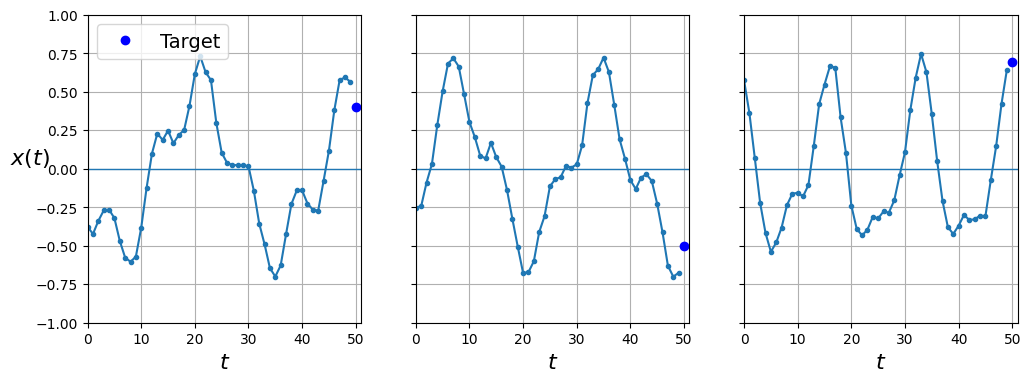

In [6]:
def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

def plot_series(series, y=None, y_pred=None, x_label="$t$", y_label="$x(t)$", legend=True):
    plt.plot(series, ".-")
    if y is not None:
        plt.plot(n_steps, y, "bo", label="Target")
    if y_pred is not None:
        plt.plot(n_steps, y_pred, "rx", markersize=10, label="Prediction")
    plt.grid(True)
    if x_label:
        plt.xlabel(x_label, fontsize=16)
    if y_label:
        plt.ylabel(y_label, fontsize=16, rotation=0)
    plt.hlines(0, 0, 100, linewidth=1)
    plt.axis([0, n_steps + 1, -1, 1])
    if legend and (y or y_pred):
        plt.legend(fontsize=14, loc="upper left")

fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
for col in range(3):
    plt.sca(axes[col])
    plot_series(X_valid[col, :, 0], y_valid[col, 0],
                y_label=("$x(t)$" if col==0 else None),
                legend=(col == 0))
plt.show()

In [2]:
import tensorflow as tf
from tensorflow import keras

In [2]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from tensorflow import keras

In [7]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_valid, y_valid))

Epoch 1/20


2025-09-01 10:20:48.296451: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


219/219 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - loss: 0.0299 - val_loss: 0.0076
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 450s 2s/step - loss: 0.0062 - val_loss: 0.0055
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3301s 15s/step - loss: 0.0049 - val_loss: 0.0045
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 22561s 103s/step - loss: 0.0044 - val_loss: 0.0041
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2121s 10s/step - loss: 0.0041 - val_loss: 0.0039
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3344s 15s/step - loss: 0.0040 - val_loss: 0.0037
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5073s 23s/step - loss: 0.0038 - val_loss: 0.0036
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4690s 22s/step - loss: 0.0037 - val_loss: 0.0035
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5667s 26s/step - loss: 0.0037 - val_loss: 0.0035
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 544s 2s/step - loss: 0.0036 - val_loss: 0.0034
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1164s 5s/step - loss: 0.0036 - val_loss: 0.0034
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━